In [1]:
import torch
import torch.nn as nn #用来搭建神经网络
import torch.optim as optim #用来更新参数
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split#用来划分数据集
import matplotlib.pyplot as plt

(1000, 2) (1000,)


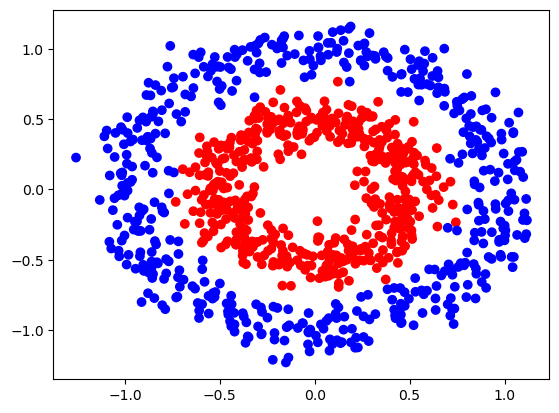

torch.Size([1000, 2]) torch.Size([1000, 1])
训练集大小: torch.Size([800, 2]), 测试集大小: torch.Size([200, 2])


In [2]:
# 准备数据，创建环形数据集

x_np, y_np = make_circles(n_samples=1000, noise=0.1, factor=0.5,random_state=42)
print(x_np.shape, y_np.shape) #(1000, 2) (1000,))
#(1000,)：一维数组，像 [0, 1, 0, ...]。
#(1000, 1)：二维矩阵，像 [[0], [1], [0], ...]。
plt.scatter(x_np[:, 0], x_np[:, 1], c=y_np, cmap='bwr')
plt.show()
# 转换为PyTorch张量
x = torch.from_numpy(x_np).float()
y = torch.from_numpy(y_np).float().reshape(1000,1) # 转换为列向量
print(x.shape, y.shape)
# 划分数据集
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"训练集大小: {x_train.shape}, 测试集大小: {x_test.shape}")

#封装数据
dataset_train = TensorDataset(x_train, y_train)
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)

dataset_test = TensorDataset(x_test, y_test)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)


In [3]:
# 定义模型
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.layer1 = nn.Linear(2, 8) # 输入层到隐藏层
        self.gelu = nn.GELU() # 激活函数
        self.layer2 = nn.Linear(8, 4) # 隐藏层到输出层
        self.layer3 = nn.Linear(4, 1) # 输出层
        self.sigmoid = nn.Sigmoid() # 输出层的Sigmoid函数
    def forward(self, x):
        x = self.layer1(x)
        x = self.gelu(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        return x
    
model = LogisticRegressionModel()

In [4]:
# 损失函数
criterion = nn.BCELoss() # 二分类交叉熵损失函数
# 优化器
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [5]:
def test_model(model, test_loader):
    model.eval() # 设置模型为评估模式
    total = 0
    correct = 0
    with torch.no_grad(): # 不计算梯度，节省内存和计算资源
        for inputs, labels in test_loader:
            outputs = model(inputs)
            predictions = (outputs > 0.5).float() # 将输出转换为二分类结果
            correct += (predictions == labels).sum().item() # 计算正确预测的数量
            total += labels.size(0) # 计算总样本数量
    accuracy = correct / total # 计算准确率
    print(f"测试准确率: {accuracy:.4f}")



In [6]:
# 训练过程
epochs = 100
model.train() # 设置为训练模式
for epoch in range(epochs):
    for batch_x, batch_y in train_loader:
        # 前向传播
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # 反向传播并优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 每 10 轮打印一次结果并可视化
    if (epoch + 1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
        test_model(model, test_loader)
        # 可视化决策边界和训练点
    

print("训练完成！")

Epoch [1/100], Loss: 0.6912
测试准确率: 0.5550
Epoch [2/100], Loss: 0.6928
测试准确率: 0.5700
Epoch [3/100], Loss: 0.6922
测试准确率: 0.5800
Epoch [4/100], Loss: 0.6883
测试准确率: 0.6100
Epoch [5/100], Loss: 0.6840
测试准确率: 0.6300
Epoch [6/100], Loss: 0.6780
测试准确率: 0.6450
Epoch [7/100], Loss: 0.6814
测试准确率: 0.6400
Epoch [8/100], Loss: 0.6514
测试准确率: 0.6750
Epoch [9/100], Loss: 0.6607
测试准确率: 0.6950
Epoch [10/100], Loss: 0.6305
测试准确率: 0.7400
Epoch [11/100], Loss: 0.6192
测试准确率: 0.7850
Epoch [12/100], Loss: 0.6127
测试准确率: 0.8400
Epoch [13/100], Loss: 0.5856
测试准确率: 0.9050
Epoch [14/100], Loss: 0.5706
测试准确率: 0.9200
Epoch [15/100], Loss: 0.5284
测试准确率: 0.9350
Epoch [16/100], Loss: 0.5156
测试准确率: 0.9600
Epoch [17/100], Loss: 0.4599
测试准确率: 0.9700
Epoch [18/100], Loss: 0.4212
测试准确率: 0.9650
Epoch [19/100], Loss: 0.3920
测试准确率: 0.9700
Epoch [20/100], Loss: 0.3691
测试准确率: 0.9650
Epoch [21/100], Loss: 0.3521
测试准确率: 0.9800
Epoch [22/100], Loss: 0.2868
测试准确率: 0.9800
Epoch [23/100], Loss: 0.2950
测试准确率: 0.9800
Epoch [24/100], Loss